In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

print(
    "Performance Analytics Ready"
)

Performance Analytics Ready


In [2]:
fund_master = pd.read_csv(
    "data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "data/raw/02_nav_history.csv"
)

performance = pd.read_csv(
    "data/raw/07_scheme_performance.csv"
)

print(
    fund_master.shape
)

print(
    nav_history.shape
)

print(
    performance.shape
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/01_fund_master.csv'

In [3]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

print(
    fund_master.shape
)

print(
    nav_history.shape
)

print(
    performance.shape
)

(40, 15)
(46000, 3)
(40, 19)


In [4]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history = nav_history.sort_values(

    ["amfi_code","date"]

)

nav_history["daily_return"] = nav_history.groupby(

    "amfi_code"

)["nav"].pct_change()

print(

    nav_history[
        ["amfi_code","date","nav","daily_return"]
    ].head(10)

)

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


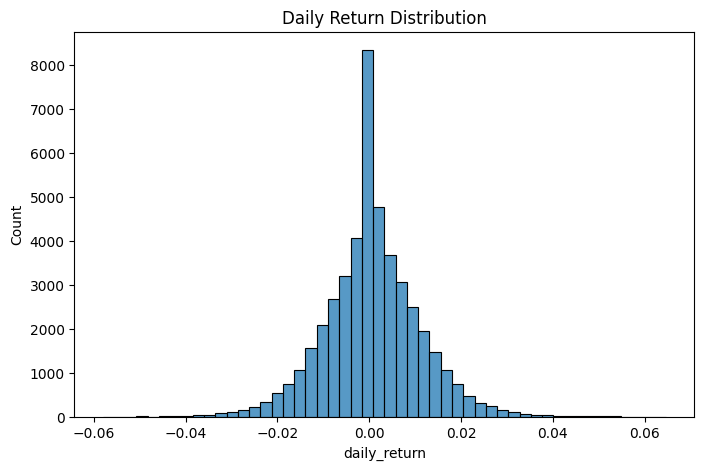

In [5]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(

    nav_history[
        "daily_return"
    ].dropna(),

    bins=50

)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [6]:
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values(
        "date"
    )

    start_nav = temp.iloc[0]["nav"]

    end_nav = temp.iloc[-1]["nav"]

    years = (

        temp.iloc[-1]["date"]

        -

        temp.iloc[0]["date"]

    ).days / 365

    cagr = (

        (end_nav / start_nav)

        **

        (1 / years)

    ) - 1

    cagr_results.append(

        [fund,cagr]

    )

cagr_df = pd.DataFrame(

    cagr_results,

    columns=[

        "amfi_code",

        "CAGR"

    ]

)

cagr_df = cagr_df.merge(

    fund_master[

        ["amfi_code","scheme_name"]

    ],

    on="amfi_code",

    how="left"

)

print(

    cagr_df.head()

)

   amfi_code      CAGR                                        scheme_name
0     100016  0.026352          HDFC Top 100 Fund - Regular Plan - Growth
1     100025  0.044551       HDFC Short Term Debt Fund - Regular - Growth
2     100033  0.300997  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3     101206  0.235205      ABSL Frontline Equity Fund - Regular - Growth
4     101207  0.079331             ABSL Small Cap Fund - Regular - Growth


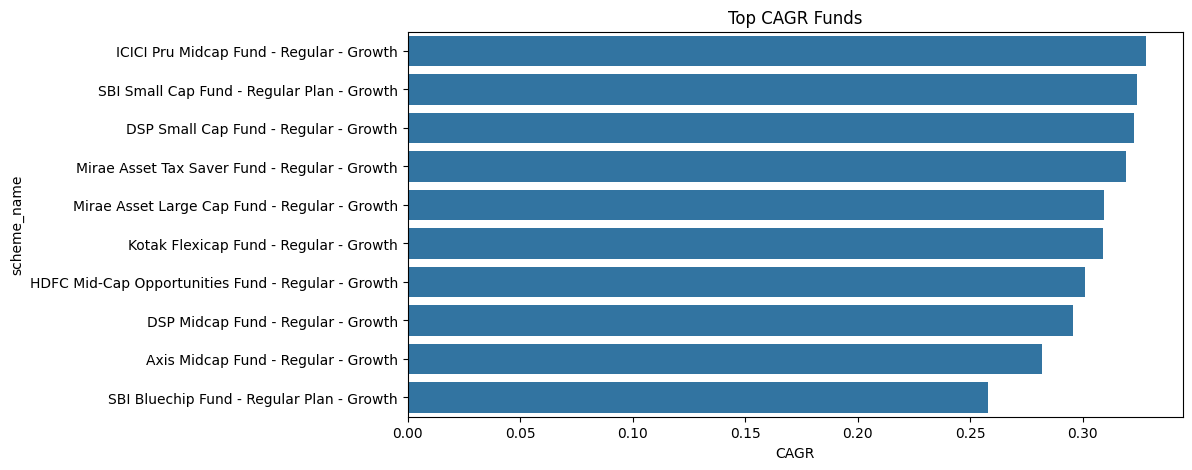

In [7]:
top_cagr = cagr_df.sort_values(

    "CAGR",

    ascending=False

).head(10)

plt.figure(
    figsize=(10,5)
)

sns.barplot(

    data=top_cagr,

    x="CAGR",

    y="scheme_name"

)

plt.title(
    "Top CAGR Funds"
)

plt.show()

In [8]:
rf = 0.065

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    annual_return = returns.mean() * 252

    annual_std = returns.std()

    sharpe = (

        annual_return - rf

    ) / annual_std * np.sqrt(
        252
    )

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(

    sharpe_results,

    columns=[
        "amfi_code",
        "Sharpe"
    ]

)

sharpe_df = sharpe_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)

print(

    sharpe_df.sort_values(

        "Sharpe",

        ascending=False

    ).head()

)

    amfi_code      Sharpe                                    scheme_name
34     148567  364.969375  Mirae Asset Large Cap Fund - Regular - Growth
30     120843  329.299480         Kotak Flexicap Fund - Regular - Growth
36     148569  311.202366  Mirae Asset Tax Saver Fund - Regular - Growth
19     119551  304.483175      SBI Bluechip Fund - Regular Plan - Growth
25     120505  297.385502       ICICI Pru Midcap Fund - Regular - Growth


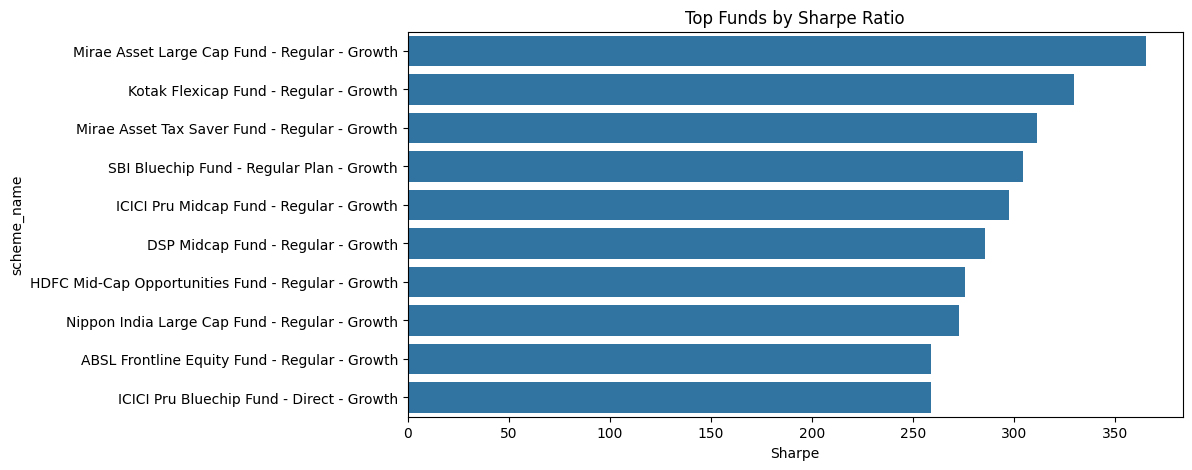

In [9]:
top_sharpe = sharpe_df.sort_values(

    "Sharpe",

    ascending=False

).head(10)

plt.figure(
    figsize=(10,5)
)

sns.barplot(

    data=top_sharpe,

    x="Sharpe",

    y="scheme_name"

)

plt.title(
    "Top Funds by Sharpe Ratio"
)

plt.show()

In [10]:
sortino_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    returns = temp[
        "daily_return"
    ].dropna()

    downside = returns[
        returns < 0
    ]

    annual_return = returns.mean() * 252

    downside_std = downside.std()

    sortino = (

        annual_return - rf

    ) / downside_std * np.sqrt(
        252
    )

    sortino_results.append(

        [fund,sortino]

    )

sortino_df = pd.DataFrame(

    sortino_results,

    columns=[

        "amfi_code",

        "Sortino"

    ]

)

sortino_df = sortino_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)

print(

    sortino_df.sort_values(

        "Sortino",

        ascending=False

    ).head()

)

    amfi_code     Sortino                                    scheme_name
34     148567  601.182382  Mirae Asset Large Cap Fund - Regular - Growth
30     120843  595.808648         Kotak Flexicap Fund - Regular - Growth
36     148569  541.022309  Mirae Asset Tax Saver Fund - Regular - Growth
19     119551  539.347317      SBI Bluechip Fund - Regular Plan - Growth
25     120505  511.396941       ICICI Pru Midcap Fund - Regular - Growth


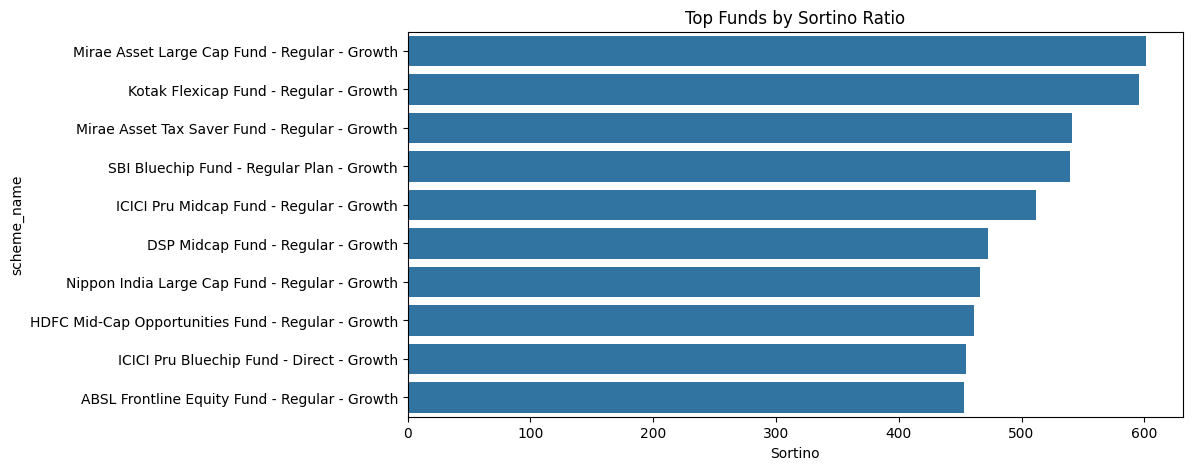

In [11]:
top_sortino = sortino_df.sort_values(

    "Sortino",

    ascending=False

).head(10)

plt.figure(
    figsize=(10,5)
)

sns.barplot(

    data=top_sortino,

    x="Sortino",

    y="scheme_name"

)

plt.title(
    "Top Funds by Sortino Ratio"
)

plt.show()

In [12]:
benchmark = nav_history.groupby(

    "date"

)[

    "daily_return"

].mean().reset_index()

benchmark = benchmark.rename(

    columns={

        "daily_return":"benchmark_return"

    }

)

print(
    benchmark.head()
)

        date  benchmark_return
0 2022-01-03               NaN
1 2022-01-04         -0.001451
2 2022-01-05          0.001977
3 2022-01-06          0.000341
4 2022-01-07          0.000627


In [13]:
alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[

        nav_history["amfi_code"] == fund

    ][

        ["date","daily_return"]

    ]

    merged = fund_data.merge(

        benchmark,

        on="date"

    ).dropna()

    slope, intercept, r, p, se = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append(

        [

            fund,

            alpha,

            beta

        ]

    )

alpha_beta = pd.DataFrame(

    alpha_beta_results,

    columns=[

        "amfi_code",

        "Alpha",

        "Beta"

    ]

)

alpha_beta = alpha_beta.merge(

    fund_master[

        ["amfi_code","scheme_name"]

    ],

    on="amfi_code"

)

print(
    alpha_beta.head()
)

   amfi_code     Alpha      Beta  \
0     100016 -0.089699  0.788441   
1     100025  0.033199  0.060713   
2     100033  0.114423  0.991590   
3     101206  0.097443  0.737015   
4     101207 -0.350741  2.878184   

                                         scheme_name  
0          HDFC Top 100 Fund - Regular Plan - Growth  
1       HDFC Short Term Debt Fund - Regular - Growth  
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
3      ABSL Frontline Equity Fund - Regular - Growth  
4             ABSL Small Cap Fund - Regular - Growth  


In [14]:
alpha_beta.to_csv(

    "alpha_beta.csv",

    index=False

)

print(
    "alpha_beta.csv saved"
)

alpha_beta.csv saved


In [15]:
drawdown_results = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[

        nav_history["amfi_code"] == fund

    ].sort_values(
        "date"
    )

    running_max = temp[
        "nav"
    ].cummax()

    drawdown = (

        temp["nav"]

        /

        running_max

    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(

        [fund,max_dd]

    )

drawdown_df = pd.DataFrame(

    drawdown_results,

    columns=[

        "amfi_code",

        "max_drawdown"

    ]

)

drawdown_df = drawdown_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)

print(

    drawdown_df.sort_values(

        "max_drawdown"

    ).head()

)

    amfi_code  max_drawdown                                 scheme_name
22     119599     -0.525742   SBI Small Cap Fund - Direct Plan - Growth
17     119095     -0.516778      Axis Small Cap Fund - Regular - Growth
4      101207     -0.354469      ABSL Small Cap Fund - Regular - Growth
39     149324     -0.311719       DSP Small Cap Fund - Regular - Growth
21     119598     -0.287060  SBI Small Cap Fund - Regular Plan - Growth


In [16]:
scorecard = cagr_df.merge(

    sharpe_df,

    on=[

        "amfi_code",

        "scheme_name"

    ]

)

scorecard = scorecard.merge(

    alpha_beta,

    on=[

        "amfi_code",

        "scheme_name"

    ]

)

scorecard = scorecard.merge(

    drawdown_df[

        ["amfi_code","max_drawdown"]

    ],

    on="amfi_code"

)

scorecard["score"] = (

    scorecard["CAGR"].rank(
        pct=True
    ) * 30

    +

    scorecard["Sharpe"].rank(
        pct=True
    ) * 25

    +

    scorecard["Alpha"].rank(
        pct=True
    ) * 20

    +

    (

        1 -

        scorecard[
            "max_drawdown"
        ].rank(
            pct=True
        )

    ) * 25

)

scorecard["score"] = (

    scorecard["score"]

    /

    scorecard["score"].max()

) * 100

print(

    scorecard.sort_values(

        "score",

        ascending=False

    ).head()

)

    amfi_code      CAGR                                        scheme_name  \
25     120505  0.328016           ICICI Pru Midcap Fund - Regular - Growth   
36     148569  0.319245      Mirae Asset Tax Saver Fund - Regular - Growth   
2      100033  0.300997  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
34     148567  0.309499      Mirae Asset Large Cap Fund - Regular - Growth   
19     119551  0.257849          SBI Bluechip Fund - Regular Plan - Growth   

        Sharpe     Alpha      Beta  max_drawdown       score  
25  297.385502  0.102647  1.194815     -0.181885  100.000000  
36  311.202366  0.096473  1.174586     -0.163967   94.152047  
2   275.612083  0.114423  0.991590     -0.162172   90.204678  
34  364.969375  0.181968  0.557134     -0.112657   89.327485  
19  304.483175  0.141513  0.562931     -0.150124   88.742690  


In [17]:
scorecard.to_csv(

    "fund_scorecard.csv",

    index=False

)

print(
    "fund_scorecard.csv saved"
)

fund_scorecard.csv saved


In [18]:
top5 = scorecard.sort_values(

    "score",

    ascending=False

).head(5)[

    "amfi_code"

].tolist()

top_nav = nav_history[

    nav_history[
        "amfi_code"
    ].isin(
        top5
    )

].copy()

top_nav = top_nav.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)

In [19]:
fig = px.line(

    top_nav,

    x="date",

    y="nav",

    color="scheme_name",

    title="Top 5 Funds Benchmark Comparison"

)

fig.show()

In [20]:
fig.write_html(

    "benchmark_comparison_chart.html"

)

print(
    "Benchmark chart saved"
)

Benchmark chart saved
